In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/gender_output_2025-10-09 11:31:59.174931_ContrastiveLoss_gru_mlp/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

7350

In [4]:
print(df_all)

      batch_size  learning_rate  split_count  cnt_min  cnt_max  embedding_dim  \
0             16          0.001            3       10      100             32   
1             16          0.001            3       10      100             32   
2             16          0.001            3       10      100             32   
3             16          0.001            3       10      100             32   
4             16          0.001            3       10      100             32   
...          ...            ...          ...      ...      ...            ...   
7345         128          0.001            3       10      100             32   
7346         128          0.001            3       10      100             32   
7347         128          0.001            3       10      100             32   
7348         128          0.001            3       10      100             32   
7349         128          0.001            3       10      100             32   

      category_embedding_di

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = scaled[:, 0] - scaled[:, 1]
df_all['ripser_weighted'] = weighted_sum

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [8]:
df_all = df_all.set_index('checkpoint')

In [9]:
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })

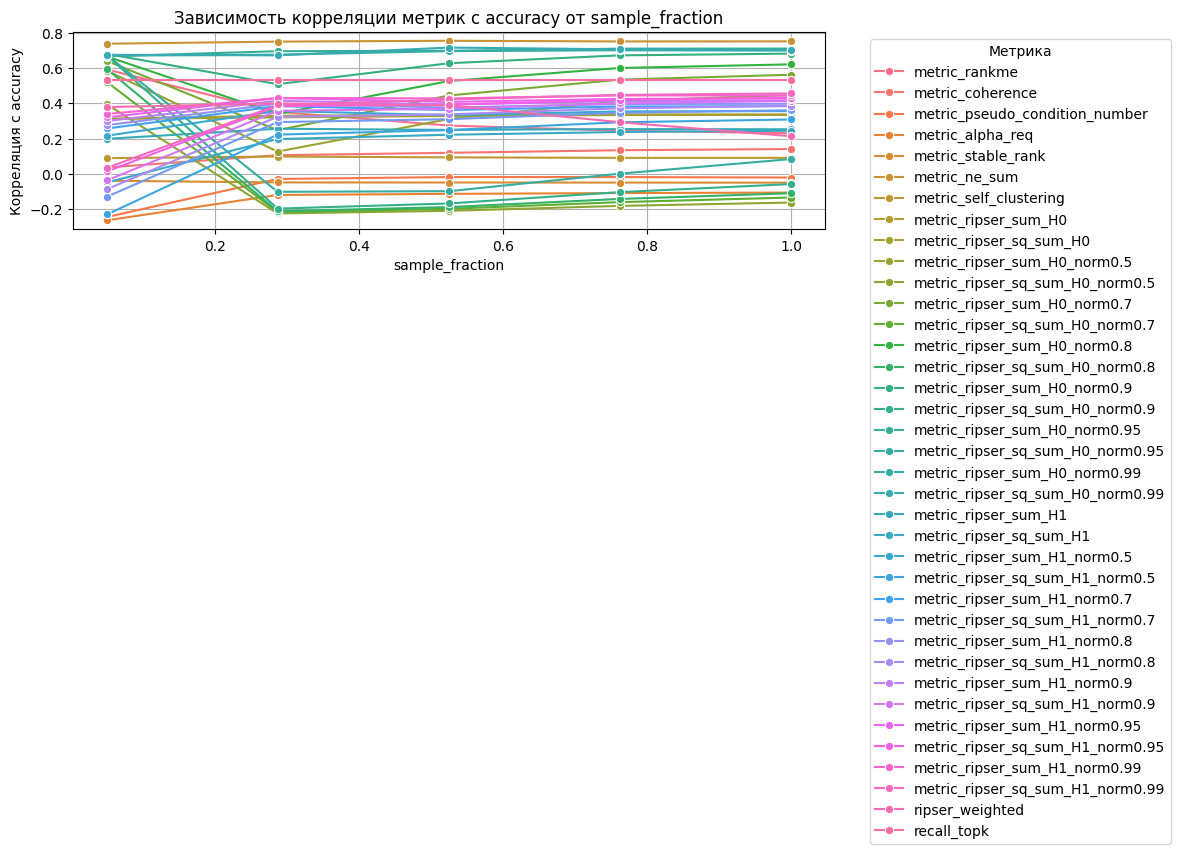

In [10]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [11]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.591360
1               0.05                  metric_coherence     0.036844
2               0.05    metric_pseudo_condition_number    -0.243270
3               0.05                  metric_alpha_req    -0.261973
4               0.05                metric_stable_rank    -0.038199
..               ...                               ...          ...
180             1.00  metric_ripser_sq_sum_H1_norm0.95     0.432086
181             1.00     metric_ripser_sum_H1_norm0.99     0.444336
182             1.00  metric_ripser_sq_sum_H1_norm0.99     0.456128
183             1.00                   ripser_weighted     0.213754
184             1.00                       recall_topk     0.534631

[185 rows x 3 columns]


In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.748323
metric_ripser_sum_H0_norm0.95       0.695539
metric_ripser_sq_sum_H0_norm0.99    0.693877
metric_ripser_sum_H0_norm0.99       0.687830
metric_ripser_sum_H0_norm0.9        0.633489
metric_ripser_sum_H0_norm0.8        0.550251
recall_topk                         0.534631
metric_ripser_sum_H0_norm0.7        0.485526
metric_ripser_sum_H1_norm0.99       0.417284
metric_ripser_sum_H1_norm0.95       0.401894
metric_ripser_sum_H1_norm0.9        0.386681
metric_ripser_sum_H0_norm0.5        0.376328
metric_ripser_sum_H1_norm0.8        0.368732
metric_ripser_sum_H1_norm0.7        0.353821
metric_ripser_sq_sum_H1_norm0.99    0.350065
metric_rankme                       0.338666
ripser_weighted                     0.334759
metric_ripser_sum_H0                0.330253
metric_ripser_sq_sum_H1_norm0.95    0.328564
metric_ripser_sq_sum_H0             0.325566
metric_ripser_sum_H1_norm0.5        0.323320
metric_ripser_sq_sum_H1_norm0.9     0.300915
met

In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.750789
metric_ripser_sum_H0_norm0.95       0.709883
metric_ripser_sq_sum_H0_norm0.99    0.702043
metric_ripser_sum_H0_norm0.99       0.698283
metric_ripser_sum_H0_norm0.9        0.681168
metric_ripser_sum_H0_norm0.8        0.620596
metric_ripser_sum_H0_norm0.7        0.561641
recall_topk                         0.534631
metric_ripser_sq_sum_H1_norm0.99    0.456128
metric_ripser_sum_H0_norm0.5        0.447155
metric_ripser_sum_H1_norm0.99       0.444336
metric_ripser_sq_sum_H1_norm0.95    0.432086
metric_ripser_sum_H1_norm0.95       0.426305
metric_ripser_sum_H1_norm0.9        0.413890
metric_ripser_sq_sum_H1_norm0.9     0.413587
metric_ripser_sum_H1_norm0.8        0.397570
metric_ripser_sq_sum_H1_norm0.8     0.385833
metric_ripser_sum_H1_norm0.7        0.383676
metric_ripser_sq_sum_H1_norm0.7     0.361045
metric_ripser_sum_H1_norm0.5        0.355912
metric_ripser_sum_H0                0.337121
metric_ripser_sq_sum_H0             0.334197
met

In [13]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.743274
metric_ripser_sum_H0_norm0.95       0.680540
metric_ripser_sq_sum_H0_norm0.99    0.673005
metric_ripser_sum_H0_norm0.99       0.672610
metric_ripser_sum_H0_norm0.9        0.593969
recall_topk                         0.534631
metric_ripser_sum_H0_norm0.8        0.502313
metric_rankme                       0.471623
metric_ripser_sum_H0_norm0.7        0.443783
metric_ripser_sum_H1_norm0.99       0.384916
metric_ripser_sum_H1_norm0.95       0.375165
metric_ripser_sum_H1_norm0.9        0.357001
metric_ripser_sum_H0_norm0.5        0.355317
metric_ripser_sum_H1_norm0.8        0.337106
metric_ripser_sum_H0                0.321511
metric_ripser_sum_H1_norm0.7        0.320881
metric_ripser_sq_sum_H0             0.315825
ripser_weighted                     0.290188
metric_ripser_sum_H1_norm0.5        0.286822
metric_ripser_sq_sum_H0_norm0.95    0.286132
metric_ripser_sq_sum_H0_norm0.9     0.237404
metric_ripser_sum_H1                0.227663
met

# Overall Spearmann Corr

In [14]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })
            


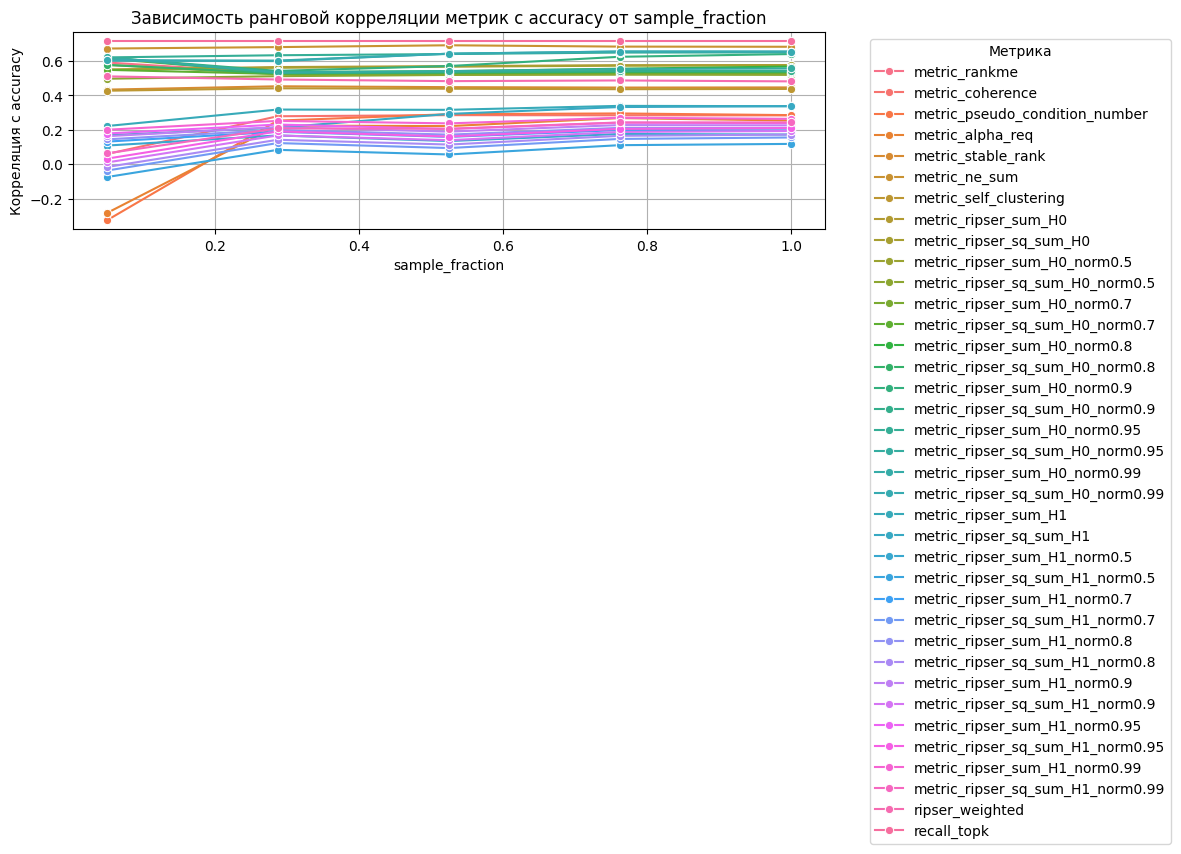

In [15]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [16]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.717967312784951,
 'metric_ne_sum': 0.6831071172926589,
 'metric_ripser_sum_H0_norm0.99': 0.6550799650617951,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6548643370111016,
 'metric_ripser_sum_H0_norm0.95': 0.6504946471040892,
 'metric_ripser_sum_H0_norm0.9': 0.6408347349921704,
 'metric_ripser_sum_H0': 0.5769947342489944,
 'metric_ripser_sq_sum_H0': 0.5746884456858016,
 'metric_ripser_sum_H0_norm0.8': 0.5681598494931019,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5571230605252425,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5432223815326549,
 'metric_ripser_sum_H0_norm0.7': 0.5407226843498459,
 'metric_ripser_sq_sum_H0_norm0.8': 0.537779859196987,
 'metric_ripser_sq_sum_H0_norm0.7': 0.532229948770948,
 'metric_ripser_sum_H0_norm0.5': 0.5279707828236914,
 'metric_rankme': 0.5251325108627112,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5197431810457566,
 'ripser_weighted': 0.4820762685139547,
 'metric_stable_rank': 0.44689188950013065,
 'metric_self_clustering': 0.43812512505387646,
 'metric

In [17]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.717967312784951,
 'metric_ne_sum': 0.6825923811712075,
 'metric_ripser_sum_H0_norm0.95': 0.6391961255466236,
 'metric_ripser_sum_H0_norm0.99': 0.6320149130626873,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6313978455673219,
 'metric_ripser_sum_H0_norm0.9': 0.6000293050419914,
 'metric_ripser_sum_H0': 0.5679029266731475,
 'metric_ripser_sq_sum_H0': 0.5651841329307756,
 'metric_ripser_sum_H0_norm0.8': 0.5640305715036128,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5617379304441625,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5543029120875433,
 'metric_ripser_sum_H0_norm0.7': 0.5530582489711,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5431609245650615,
 'metric_rankme': 0.5388674251604414,
 'metric_ripser_sum_H0_norm0.5': 0.5375275418648109,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5337102394641233,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5138919767622916,
 'ripser_weighted': 0.4914142526920301,
 'metric_stable_rank': 0.4458465109545072,
 'metric_self_clustering': 0.43669341360625,
 'metric_rips

In [18]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.717967312784951,
 'metric_ne_sum': 0.6770037193809404,
 'metric_ripser_sum_H0_norm0.95': 0.6276156356062482,
 'metric_ripser_sum_H0_norm0.99': 0.6033065517680805,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6018583954187862,
 'metric_ripser_sum_H0_norm0.9': 0.5815993995633629,
 'metric_ripser_sq_sum_H0_norm0.95': 0.57811837146478,
 'metric_ripser_sum_H0_norm0.8': 0.5775676797540497,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5750885783919091,
 'metric_ripser_sum_H0_norm0.7': 0.5736684706984772,
 'metric_rankme': 0.5608835020169403,
 'metric_ripser_sum_H0': 0.5579654238774203,
 'metric_ripser_sq_sum_H0': 0.5552734628056697,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5533983235840241,
 'metric_ripser_sum_H0_norm0.5': 0.5509473784181308,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5370727014841252,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5047841509299469,
 'ripser_weighted': 0.5020841390543707,
 'metric_stable_rank': 0.44386168237116774,
 'metric_self_clustering': 0.43471822180747455,
 'metric

# Correlation for best checkpoint choice

In [19]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


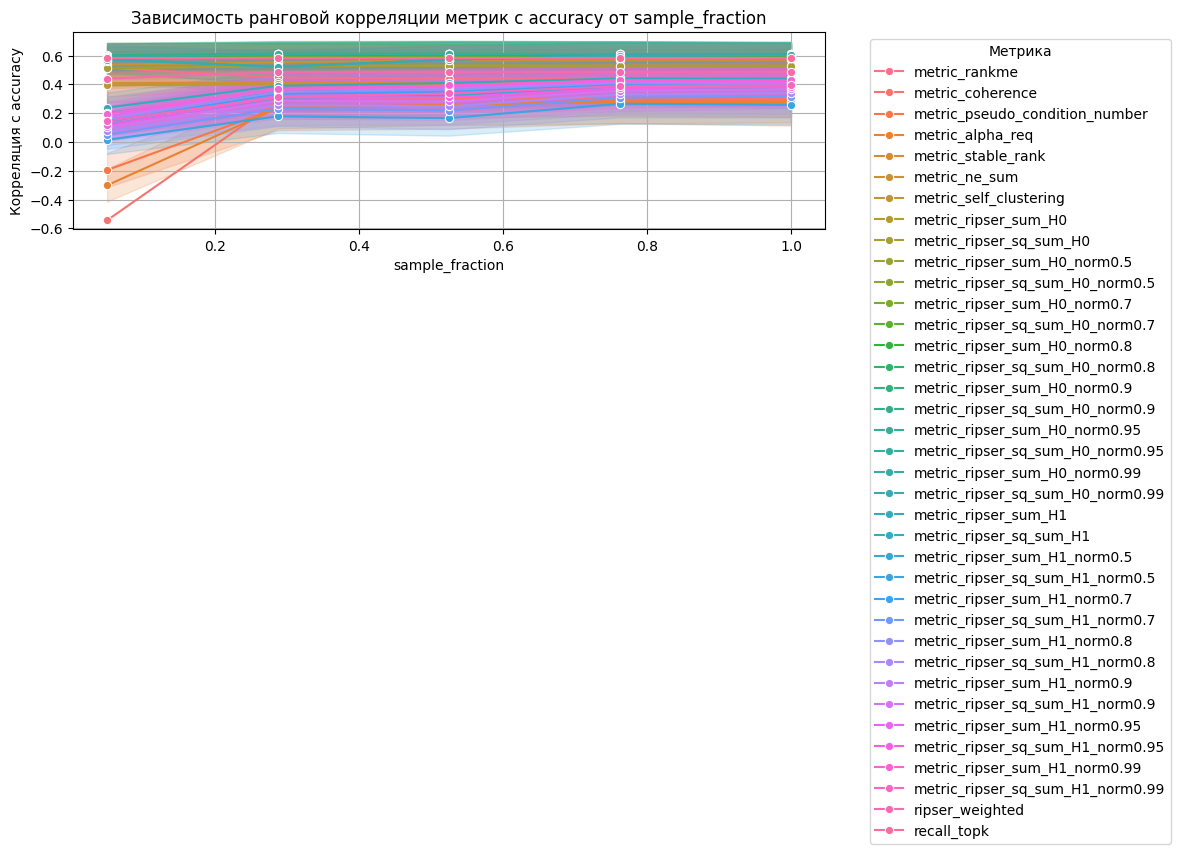

In [20]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.95': 0.6096083834036873,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6093855633938052,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6093764482721237,
 'metric_ripser_sum_H0_norm0.9': 0.6083273828416067,
 'metric_ripser_sum_H0_norm0.99': 0.6042700474664718,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6038057508905847,
 'metric_ripser_sum_H0_norm0.8': 0.6026390348752517,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6025155297209713,
 'metric_ripser_sum_H0_norm0.7': 0.5950334237310714,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5935027017544381,
 'metric_ripser_sq_sum_H0_norm0.5': 0.583173804823738,
 'metric_ripser_sum_H0_norm0.5': 0.5828026061811382,
 'recall_topk': 0.582732937989324,
 'metric_ne_sum': 0.5660368939020523,
 'metric_ripser_sum_H0': 0.5298030510719055,
 'metric_ripser_sq_sum_H0': 0.5294421283541234,
 'ripser_weighted': 0.4879166548840003,
 'metric_rankme': 0.4435468547464157,
 'metric_ripser_sum_H1': 0.43923534285002536,
 'metric_ripser_sum_H1_norm0.99': 0.42746586380692075

In [22]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.9': 0.6084276978699757,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6073797794762802,
 'metric_ripser_sum_H0_norm0.95': 0.606477319484376,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6061859442401314,
 'metric_ripser_sum_H0_norm0.8': 0.6038725691825959,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6019365519749714,
 'metric_ripser_sum_H0_norm0.7': 0.5997869328460605,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5963612893456575,
 'metric_ripser_sum_H0_norm0.5': 0.584521957257657,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5839615393116957,
 'recall_topk': 0.5827329379893241,
 'metric_ripser_sum_H0_norm0.99': 0.5741485147986644,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5732746772943028,
 'metric_ne_sum': 0.5581697017491521,
 'metric_ripser_sq_sum_H0': 0.5258077729558597,
 'metric_ripser_sum_H0': 0.5257481388297173,
 'ripser_weighted': 0.47694804399814256,
 'metric_rankme': 0.4572633042959386,
 'metric_stable_rank': 0.4092230260392925,
 'metric_self_clustering': 0.39845928912331285,
 'metri

In [23]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.9': 0.6077144538940311,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6049274775490981,
 'metric_ripser_sum_H0_norm0.8': 0.6024448106868088,
 'metric_ripser_sum_H0_norm0.7': 0.6011656911540767,
 'metric_ripser_sum_H0_norm0.95': 0.6009171035480374,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6002880806227484,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5981527722682304,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5970687514902038,
 'recall_topk': 0.582732937989324,
 'metric_ripser_sum_H0_norm0.5': 0.5827196921127079,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5789816406833693,
 'metric_ripser_sum_H0_norm0.99': 0.5490218426101016,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5464364263388456,
 'metric_ne_sum': 0.544941687502894,
 'metric_ripser_sum_H0': 0.5196600803745778,
 'metric_ripser_sq_sum_H0': 0.5196377168772949,
 'metric_rankme': 0.4810844902023543,
 'ripser_weighted': 0.4626749458995141,
 'metric_stable_rank': 0.41104683359513255,
 'metric_self_clustering': 0.3973093705099054,
 'metric

# Linear correlation of epoch choice

In [24]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

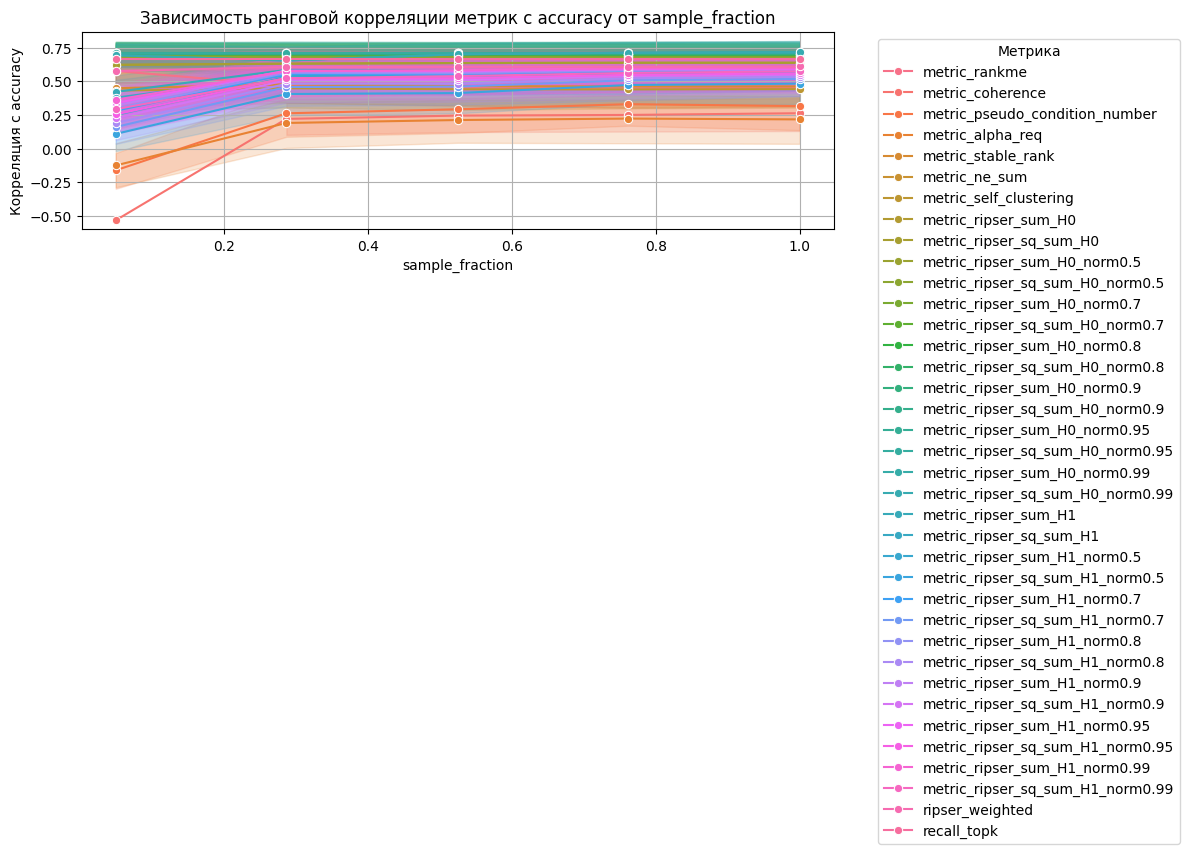

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [26]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.99       0.717007
metric_ripser_sq_sum_H0_norm0.99    0.716941
metric_ripser_sum_H0_norm0.95       0.712260
metric_ripser_sq_sum_H0_norm0.95    0.711779
metric_ripser_sum_H0_norm0.9        0.708013
metric_ripser_sq_sum_H0_norm0.9     0.707462
metric_ripser_sum_H0_norm0.8        0.701045
metric_ripser_sq_sum_H0_norm0.8     0.700180
metric_ripser_sum_H0_norm0.7        0.693758
metric_ripser_sq_sum_H0_norm0.7     0.692445
metric_ne_sum                       0.688392
metric_ripser_sum_H0_norm0.5        0.673645
metric_ripser_sq_sum_H0_norm0.5     0.670866
recall_topk                         0.670279
metric_ripser_sq_sum_H0             0.639113
metric_ripser_sum_H0                0.638422
ripser_weighted                     0.610964
metric_ripser_sum_H1_norm0.99       0.599722
metric_ripser_sum_H1_norm0.95       0.591972
metric_ripser_sum_H1                0.588588
metric_ripser_sum_H1_norm0.9        0.586976
metric_ripser_sum_H1_norm0.8        0.579272
met

In [27]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.9        0.710751
metric_ripser_sum_H0_norm0.95       0.709871
metric_ripser_sq_sum_H0_norm0.9     0.709078
metric_ripser_sq_sum_H0_norm0.95    0.708430
metric_ripser_sum_H0_norm0.8        0.706588
metric_ripser_sq_sum_H0_norm0.8     0.704224
metric_ripser_sum_H0_norm0.7        0.702008
metric_ripser_sq_sum_H0_norm0.7     0.698773
metric_ripser_sum_H0_norm0.5        0.685352
metric_ne_sum                       0.683901
metric_ripser_sq_sum_H0_norm0.5     0.679153
metric_ripser_sum_H0_norm0.99       0.675574
metric_ripser_sq_sum_H0_norm0.99    0.674517
recall_topk                         0.670279
metric_ripser_sum_H0                0.627859
metric_ripser_sq_sum_H0             0.627190
ripser_weighted                     0.592033
metric_rankme                       0.524111
metric_ripser_sum_H1                0.503861
metric_ripser_sum_H1_norm0.99       0.469952
metric_stable_rank                  0.463603
metric_ripser_sq_sum_H1             0.462237
met

# Score of best epoch

In [28]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

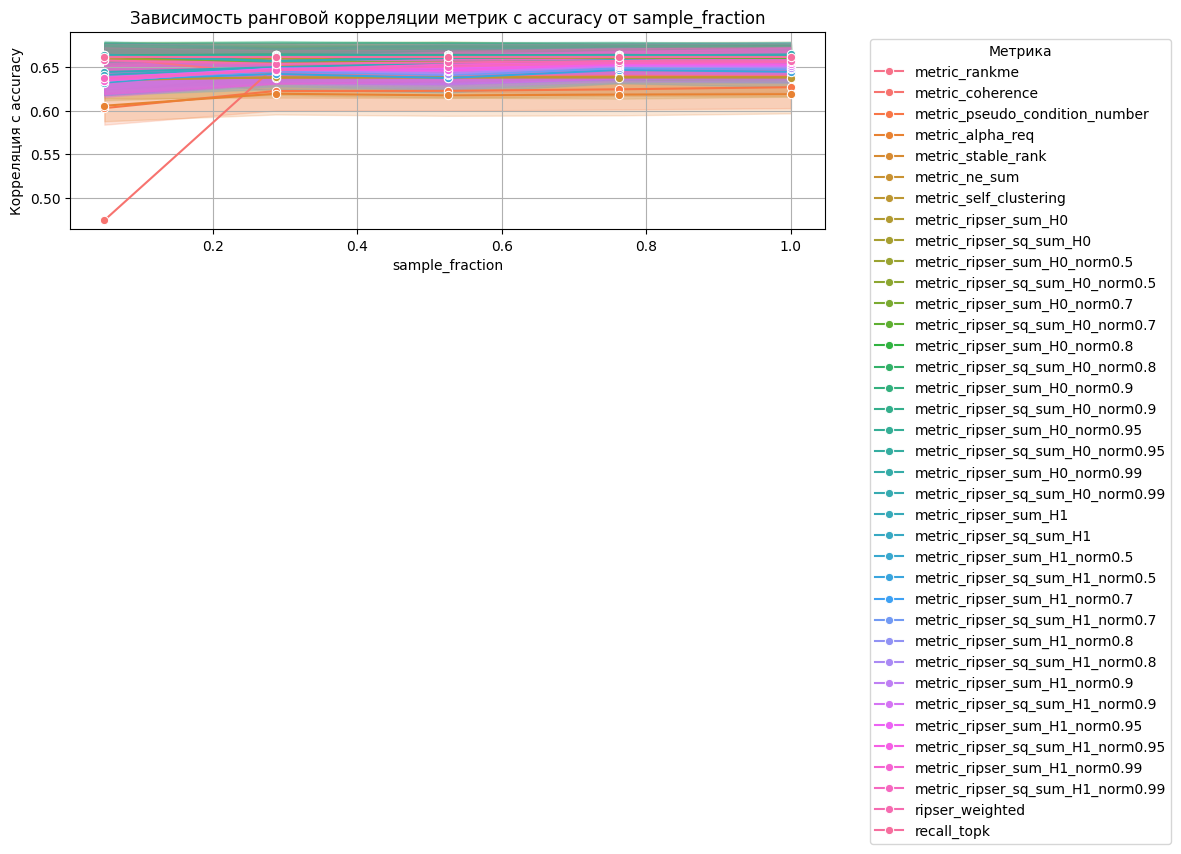

In [29]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [30]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.6635651282051281,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6634738461538461,
 'metric_ripser_sum_H0_norm0.95': 0.6631194871794872,
 'metric_ripser_sum_H0_norm0.9': 0.6631005128205127,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6630451282051282,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6630071794871795,
 'metric_ripser_sum_H0_norm0.8': 0.6623841025641025,
 'metric_ripser_sum_H0_norm0.7': 0.6621174358974359,
 'recall_topk': 0.6619461538461539,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6618958974358975,
 'metric_ripser_sum_H0_norm0.99': 0.6615461538461538,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6607605128205128,
 'metric_ripser_sq_sum_H0': 0.6603861538461537,
 'metric_ripser_sum_H0': 0.6601779487179488,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6570851282051282,
 'metric_ripser_sum_H0_norm0.5': 0.6565723076923077,
 'ripser_weighted': 0.6560410256410256,
 'metric_ripser_sum_H1': 0.652111282051282,
 'metric_coherence': 0.6513605633802817,
 'metric_ripser_sq_sum_H1': 0.6500420512820513,
 '

In [31]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.6645179487179487,
 'metric_ripser_sum_H0_norm0.99': 0.663725641025641,
 'metric_ne_sum': 0.6636076923076923,
 'metric_ripser_sum_H0_norm0.95': 0.662974358974359,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6627794871794872,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6623641025641026,
 'metric_ripser_sum_H0_norm0.9': 0.6622923076923077,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6619641025641025,
 'recall_topk': 0.6619461538461539,
 'metric_ripser_sum_H0_norm0.8': 0.6614384615384615,
 'metric_ripser_sum_H0': 0.6611743589743589,
 'metric_ripser_sq_sum_H0': 0.6610538461538461,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6607282051282051,
 'metric_ripser_sum_H0_norm0.7': 0.6604128205128205,
 'metric_ripser_sq_sum_H1': 0.6568128205128205,
 'metric_ripser_sum_H1_norm0.99': 0.6567538461538461,
 'metric_ripser_sum_H1_norm0.95': 0.6565461538461539,
 'ripser_weighted': 0.6564333333333333,
 'metric_ripser_sum_H1_norm0.8': 0.6560589743589744,
 'metric_ripser_sum_H1_norm0.7': 0.65

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.8': 0.6639435897435897,
 'metric_ripser_sq_sum_H0_norm0.9': 0.663723076923077,
 'metric_ne_sum': 0.6633628205128205,
 'metric_ripser_sum_H0_norm0.9': 0.6633397435897436,
 'metric_ripser_sum_H0_norm0.7': 0.6629435897435898,
 'metric_ripser_sum_H0_norm0.95': 0.6625794871794871,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6625320512820513,
 'metric_ripser_sum_H0_norm0.8': 0.6625153846153846,
 'recall_topk': 0.6619461538461539,
 'metric_ripser_sum_H0_norm0.99': 0.6606525641025641,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6599807692307692,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6598102564102565,
 'metric_ripser_sq_sum_H0': 0.6597166666666667,
 'metric_ripser_sum_H0_norm0.5': 0.6588525641025641,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6587589743589743,
 'metric_ripser_sum_H0': 0.6587423076923077,
 'ripser_weighted': 0.6556935897435897,
 'metric_rankme': 0.6512076923076923,
 'metric_ripser_sum_H1': 0.6470730769230769,
 'metric_coherence': 0.6460571428571429,
 'metric_rip

In [33]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [34]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme nan
metric_rankme nan
metric_coherence nan
metric_coherence nan
metric_pseudo_condition_number nan
metric_pseudo_condition_number nan
metric_alpha_req nan
metric_alpha_req nan
metric_stable_rank nan
metric_stable_rank nan
metric_ne_sum nan
metric_ne_sum nan
metric_self_clustering nan
metric_self_clustering nan
metric_ripser_sum_H0 nan
metric_ripser_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_su

# Corr of best hyperparam by metric

In [35]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

/tmp/ipykernel_1333274/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1333274/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1333274/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


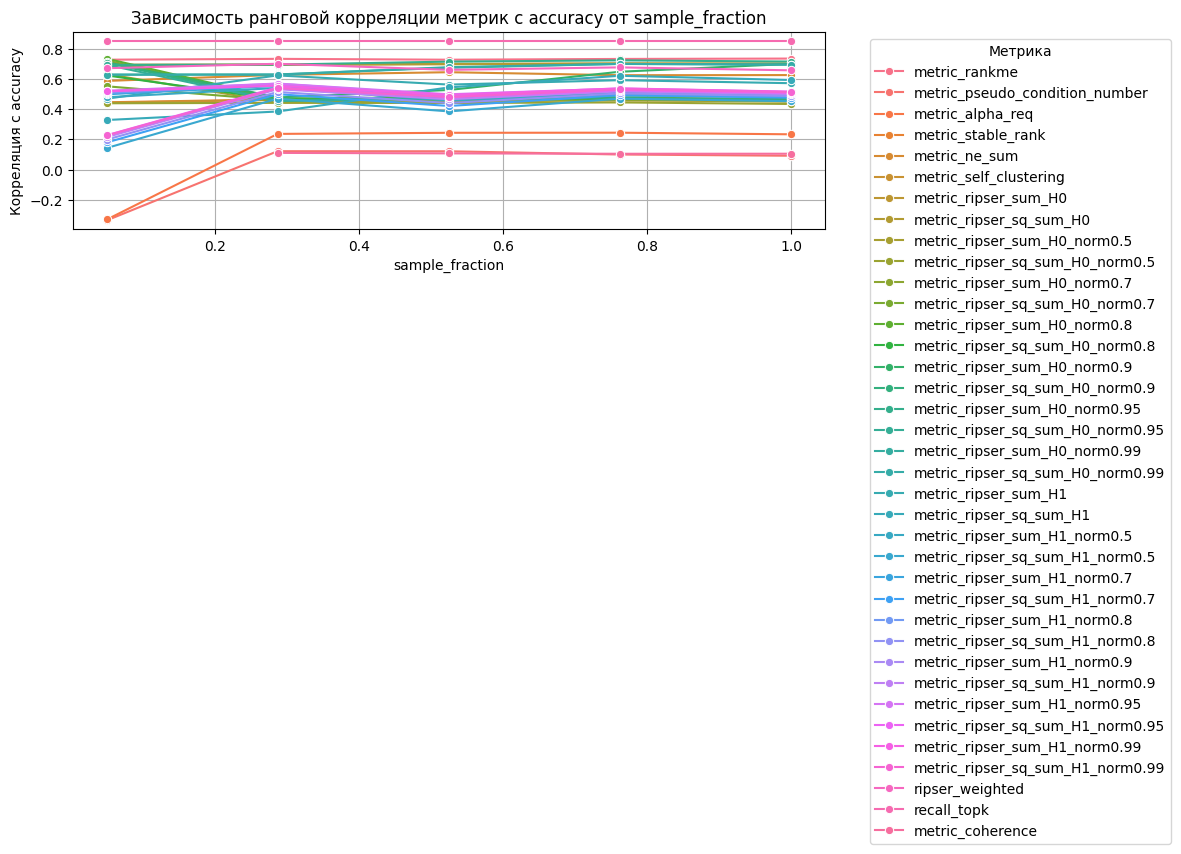

learning_rate


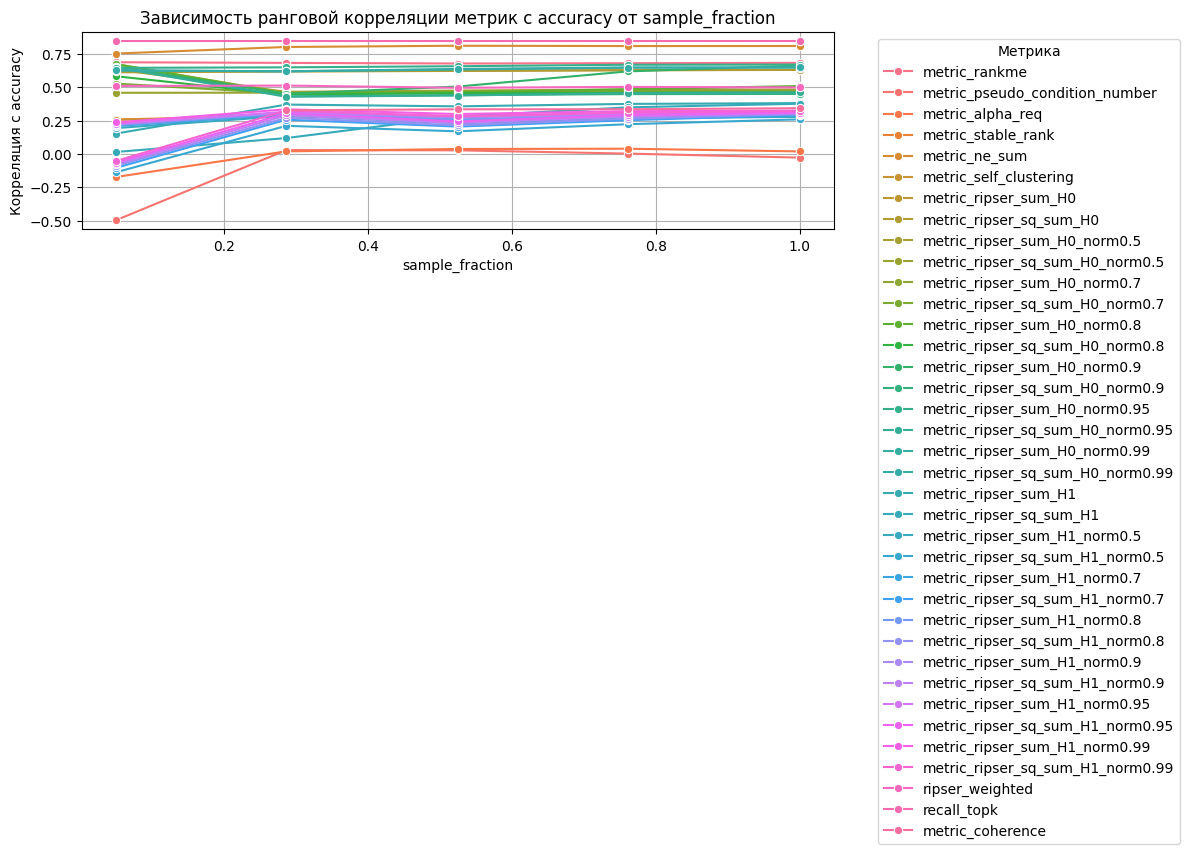

split_count


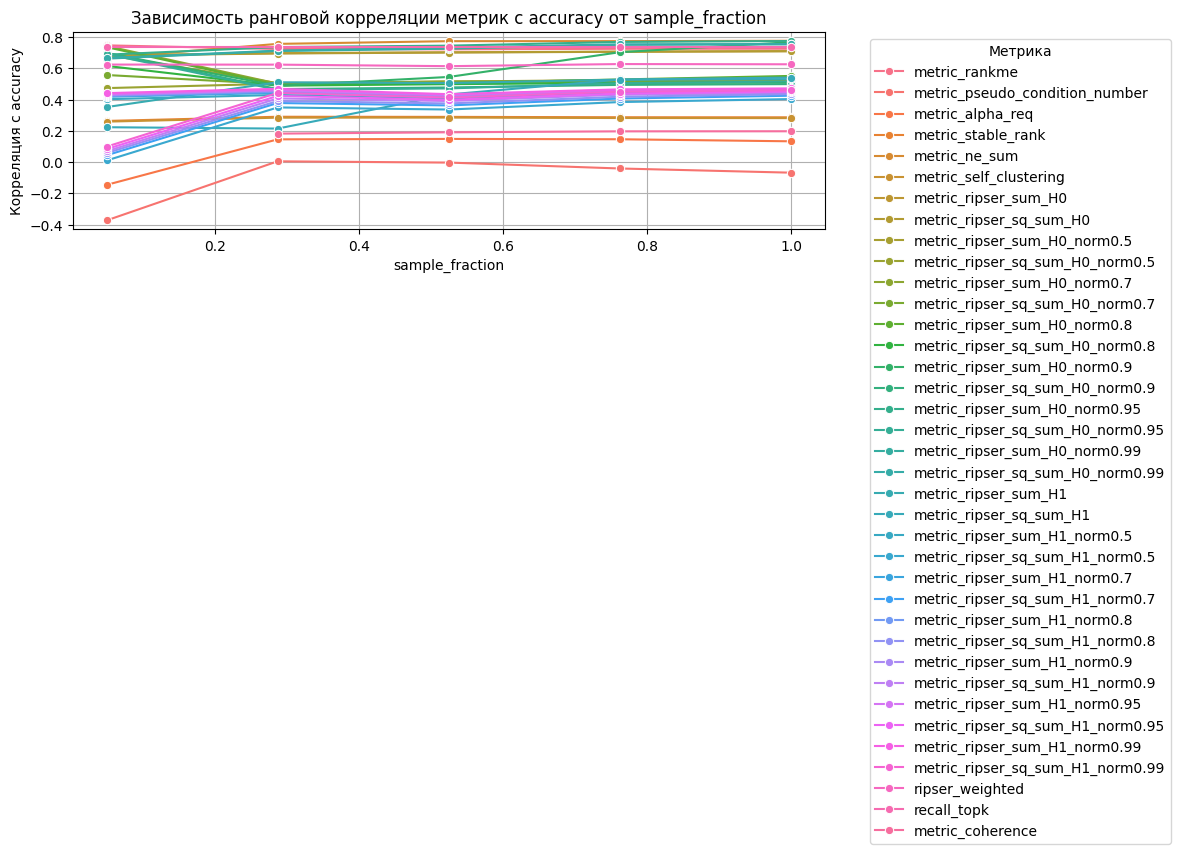

cnt_min


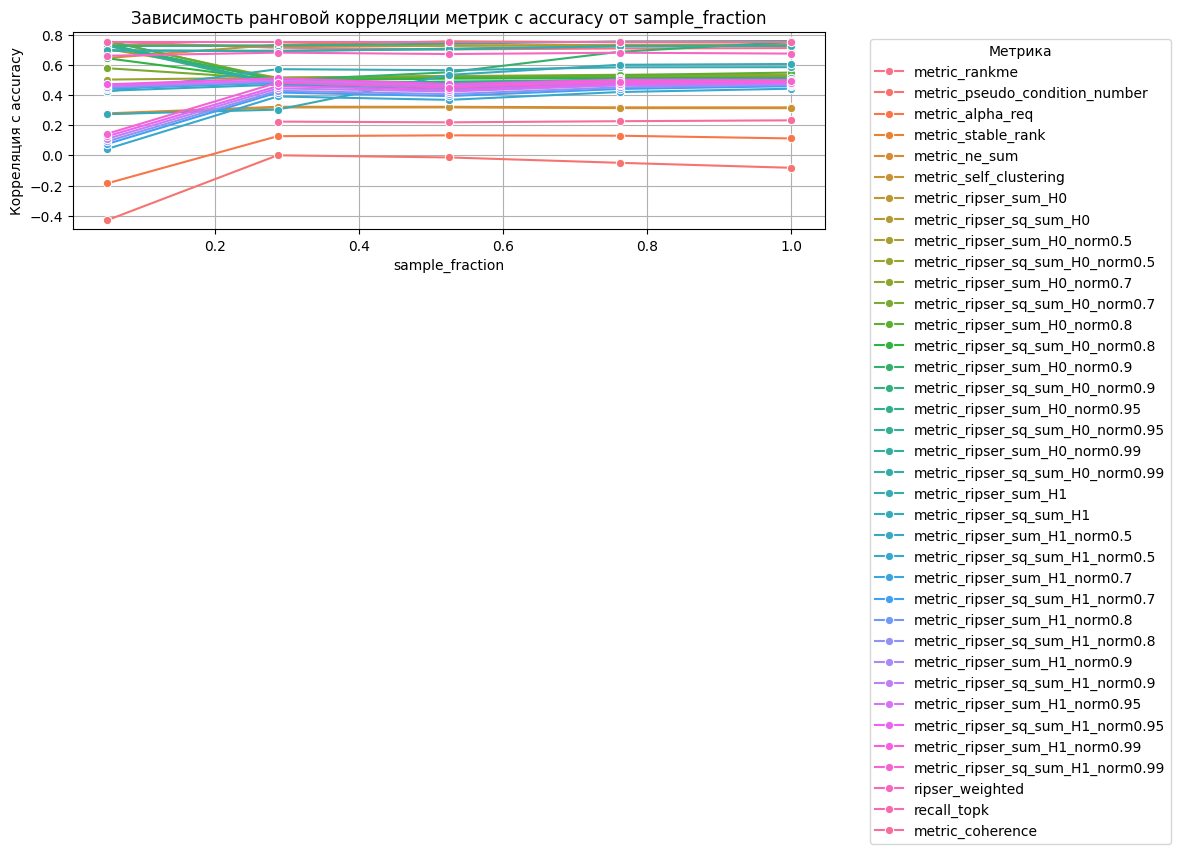

cnt_max


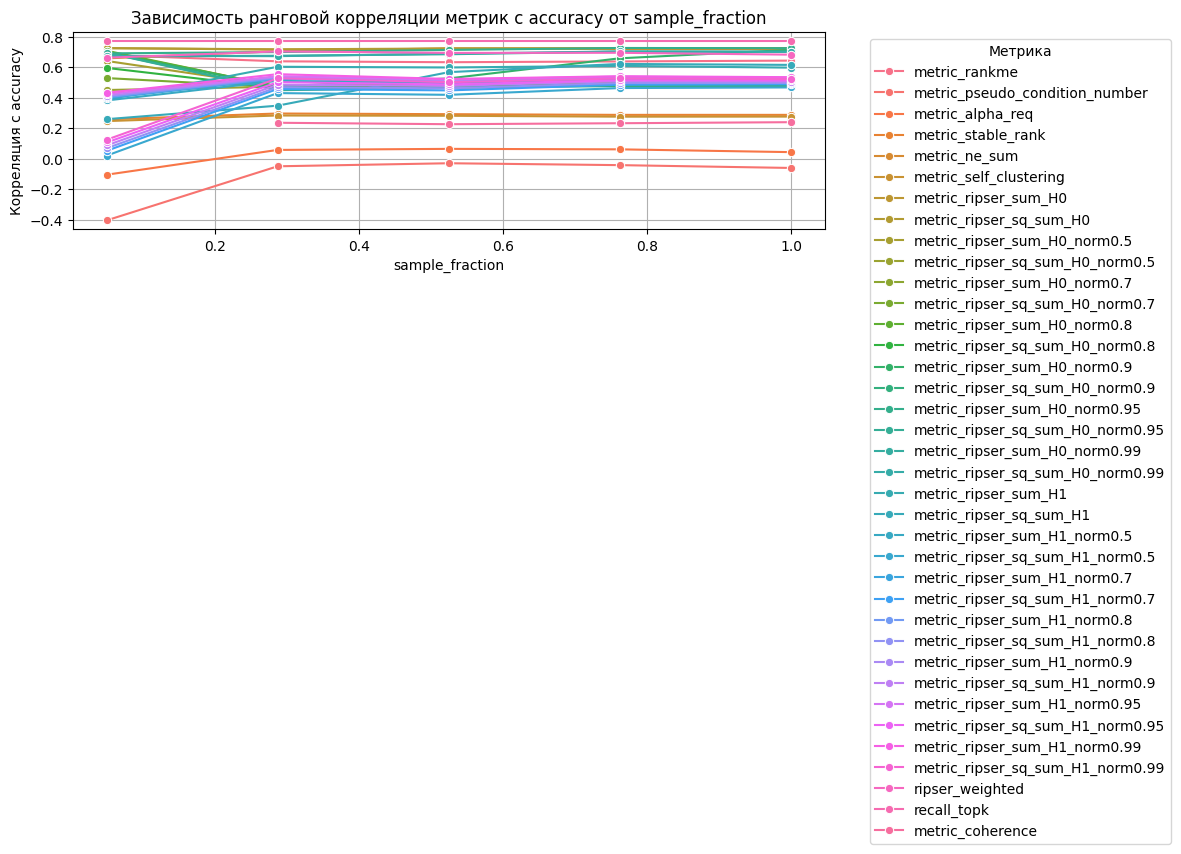

embedding_dim


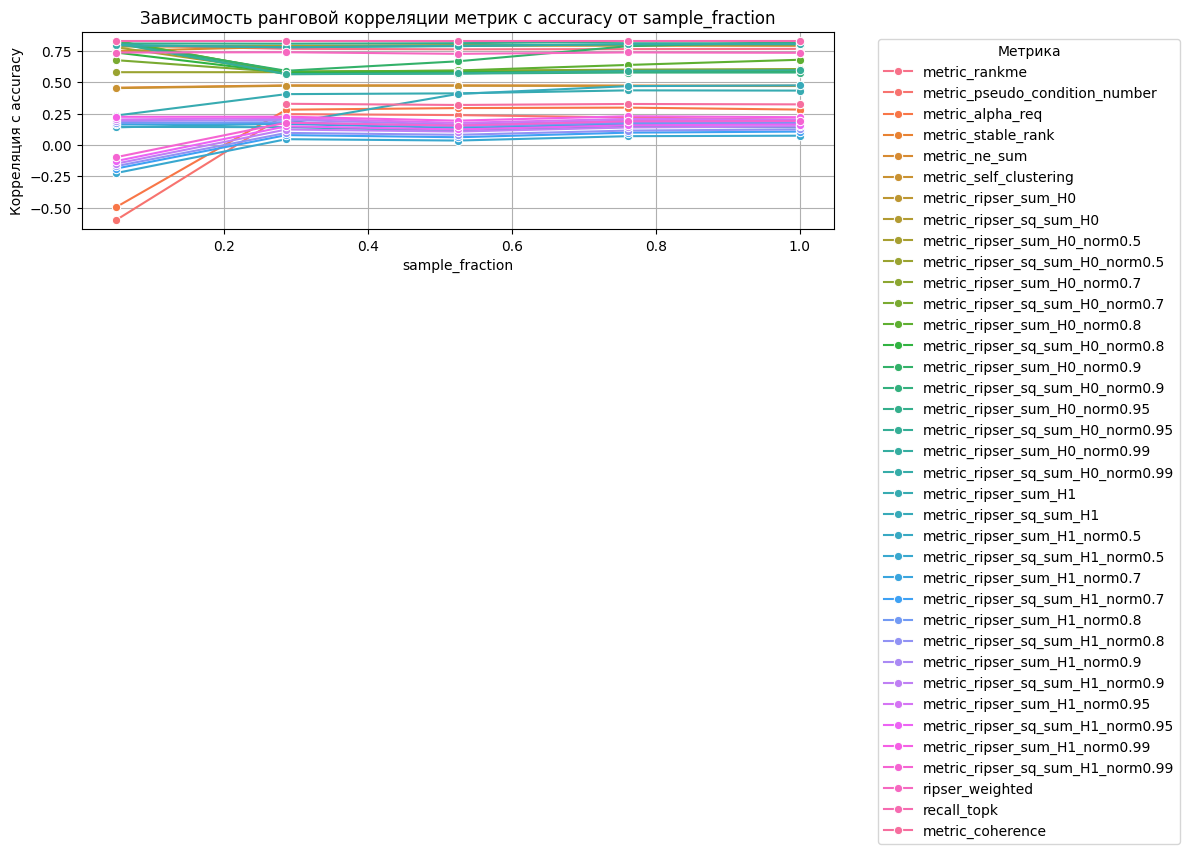

category_embedding_dim


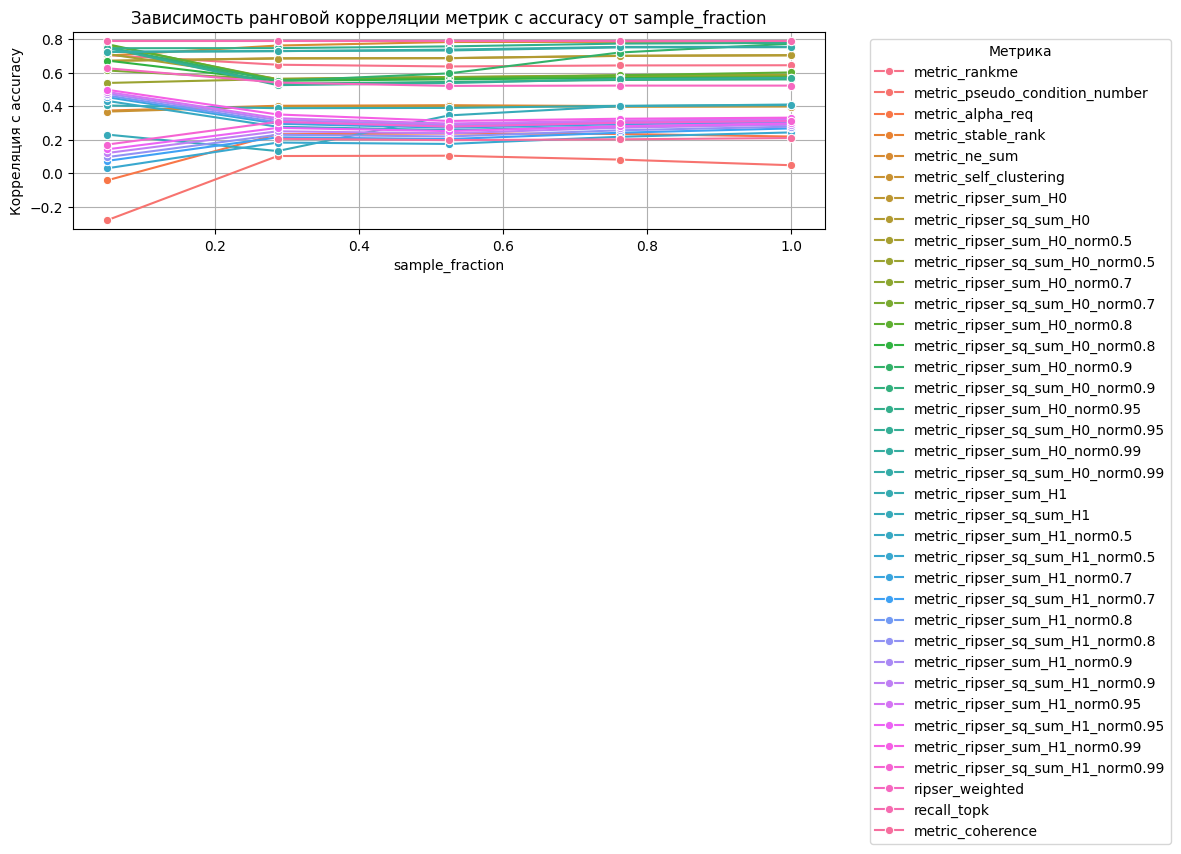

hidden_size


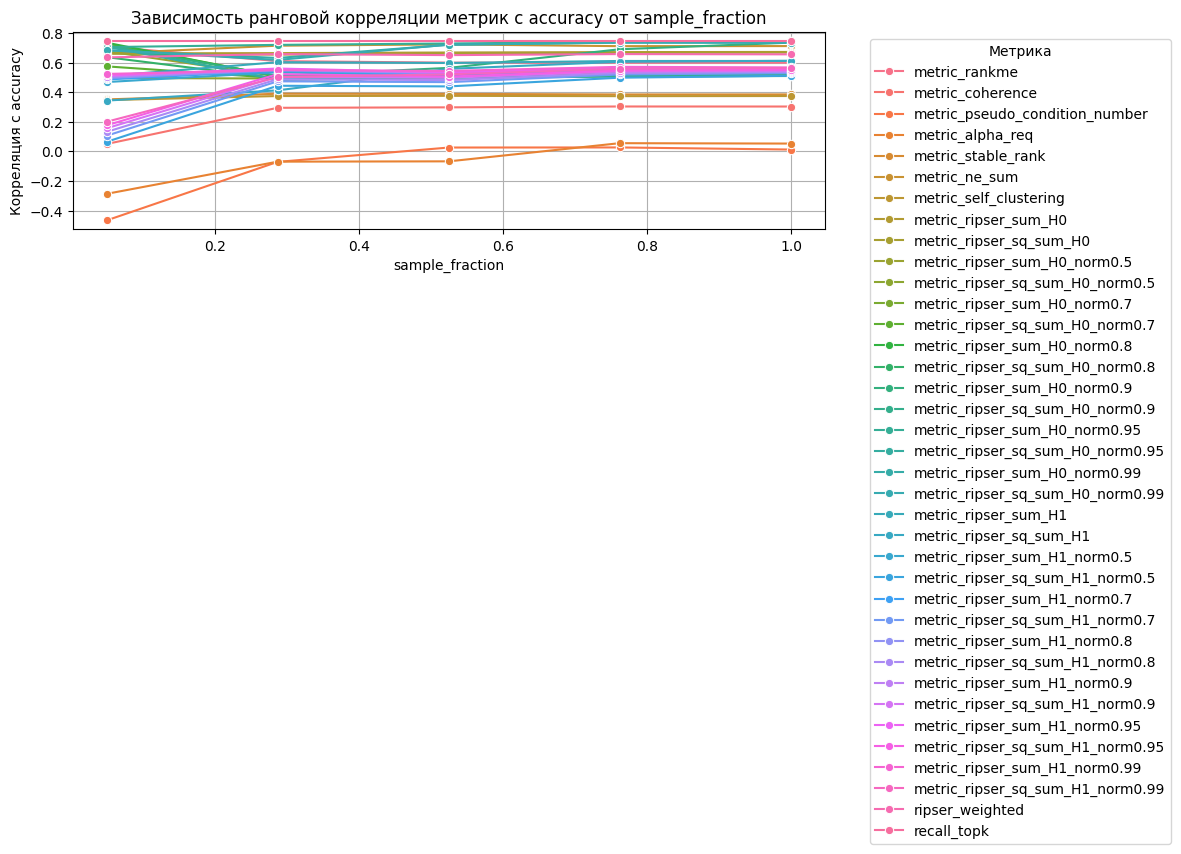

In [36]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [37]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
recall_topk                         0.851730
metric_rankme                       0.729432
metric_ripser_sum_H0                0.693779
metric_ripser_sum_H0_norm0.95       0.693170
metric_ripser_sq_sum_H0             0.692171
ripser_weighted                     0.685031
metric_ripser_sum_H0_norm0.99       0.628427
metric_ripser_sq_sum_H0_norm0.99    0.627672
metric_ne_sum                       0.606369
metric_ripser_sum_H0_norm0.8        0.601648
metric_ripser_sum_H0_norm0.9        0.593287
metric_ripser_sum_H0_norm0.7        0.592366
metric_ripser_sq_sum_H0_norm0.9     0.582646
metric_ripser_sq_sum_H0_norm0.95    0.572464
metric_ripser_sum_H1                0.545904
metric_ripser_sum_H1_norm0.95       0.545271
metric_ripser_sq_sum_H0_norm0.8     0.543258
metric_ripser_sum_H1_norm0.9        0.541646
metric_ripser_sum_H0_norm0.5        0.538321
metric_ripser_sum_H1_norm0.99       0.536270
metric_ripser_sum_H1_norm0.8        0.533259
metric_ripser_sum_H1_norm0.7        0

# Score of best hyperparams by metric

In [38]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

/tmp/ipykernel_1333274/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1333274/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1333274/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


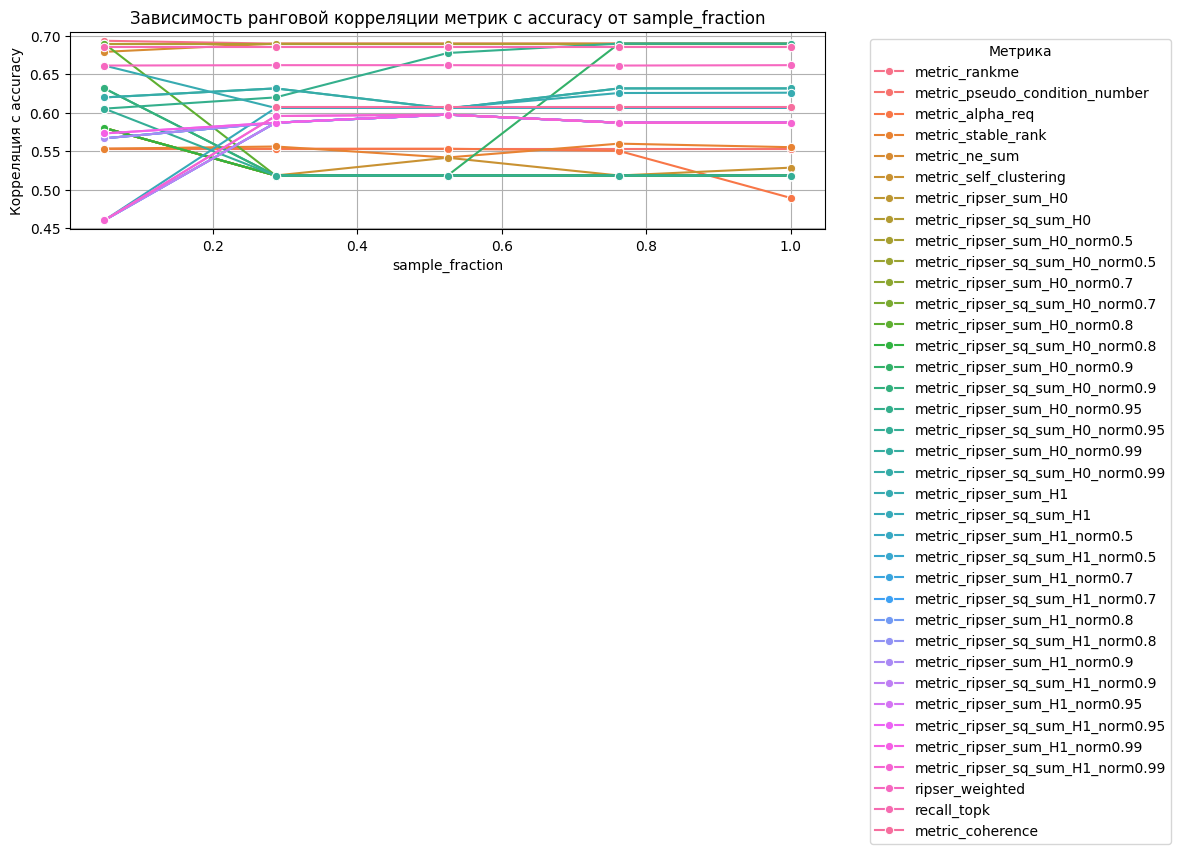

learning_rate


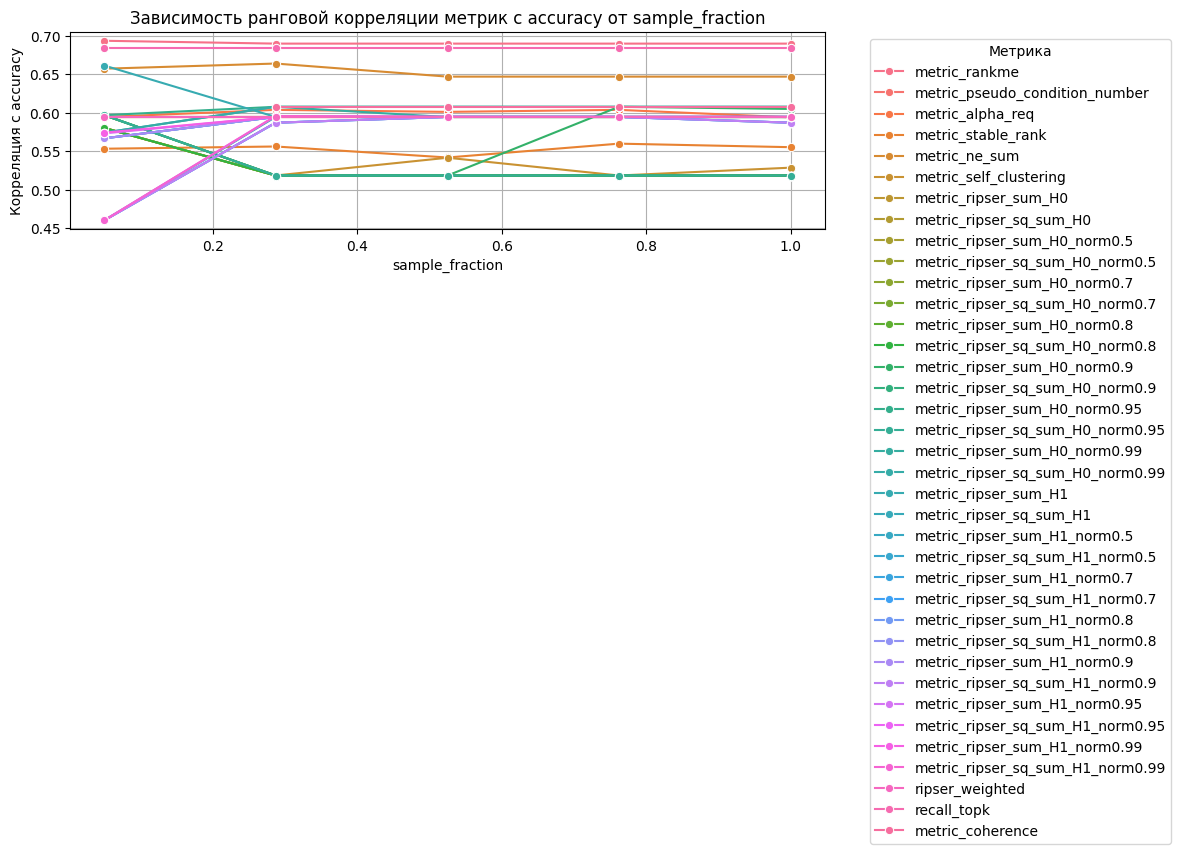

split_count


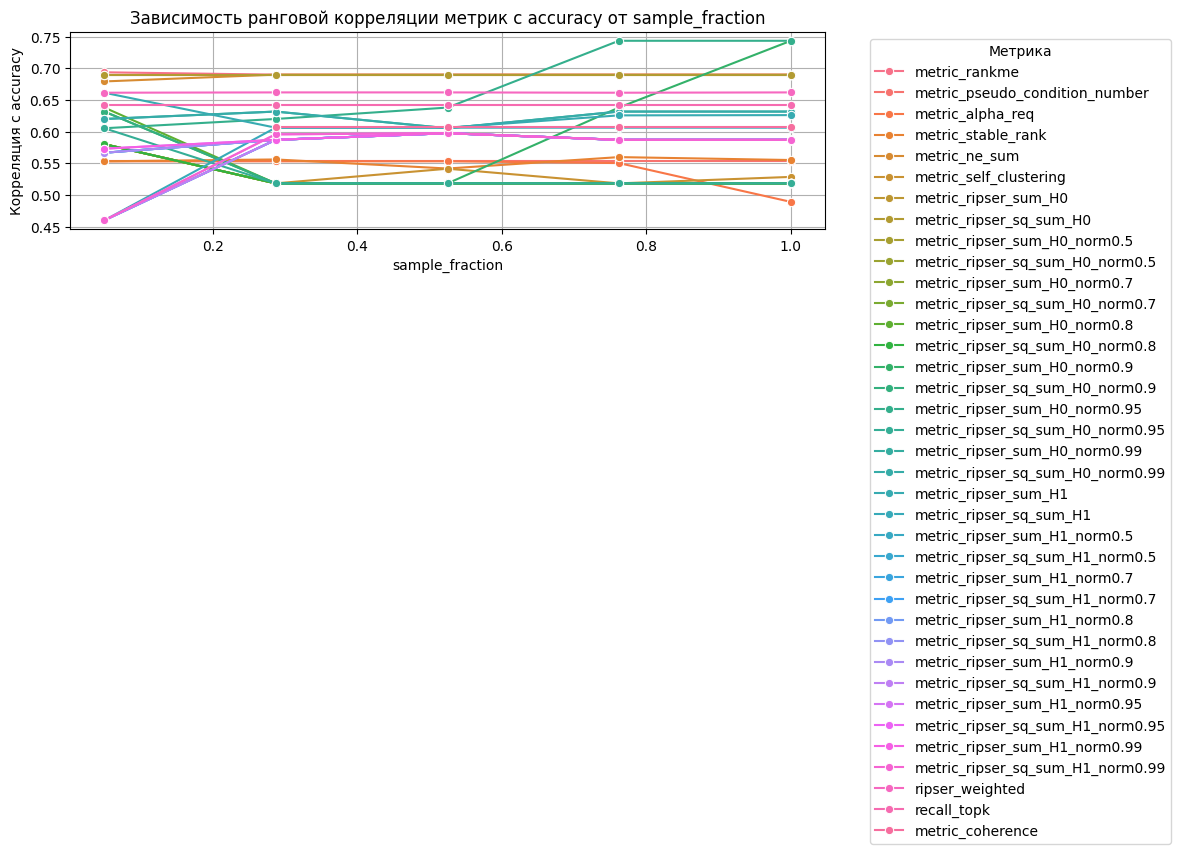

cnt_min


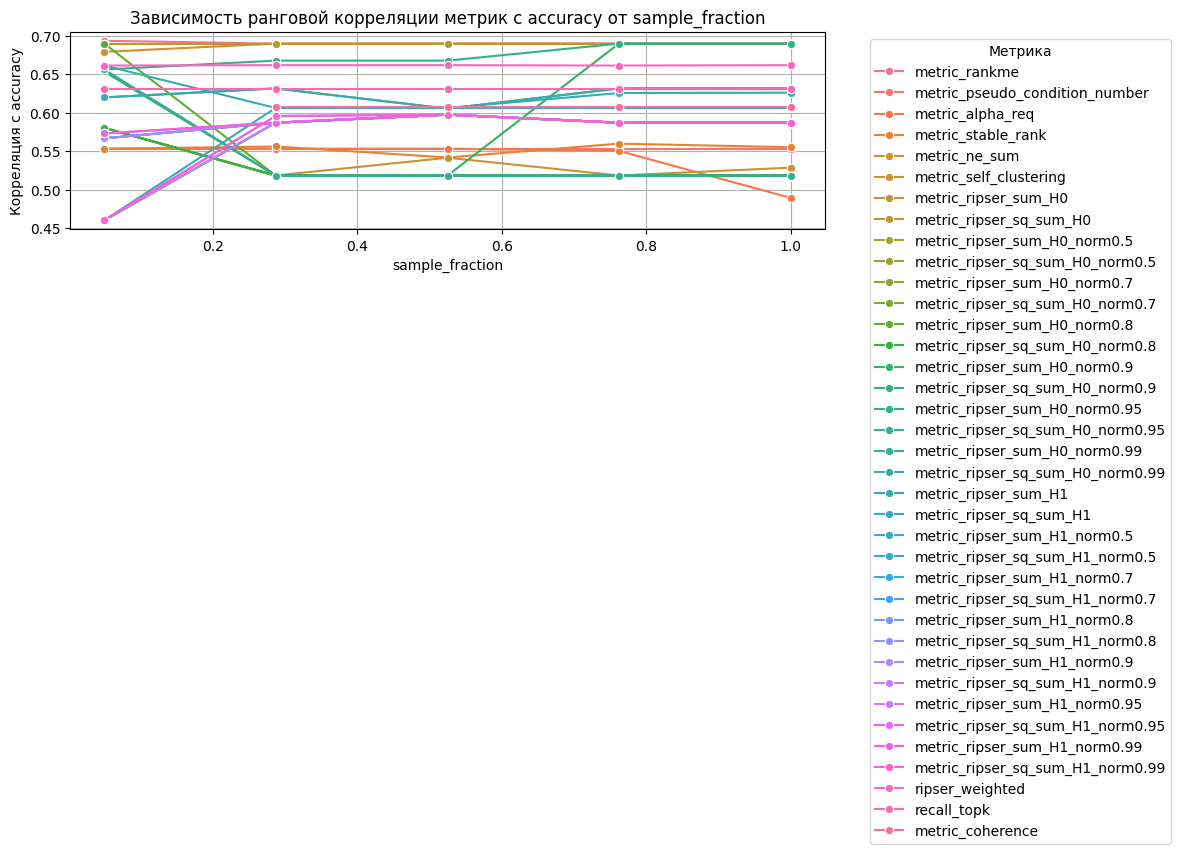

cnt_max


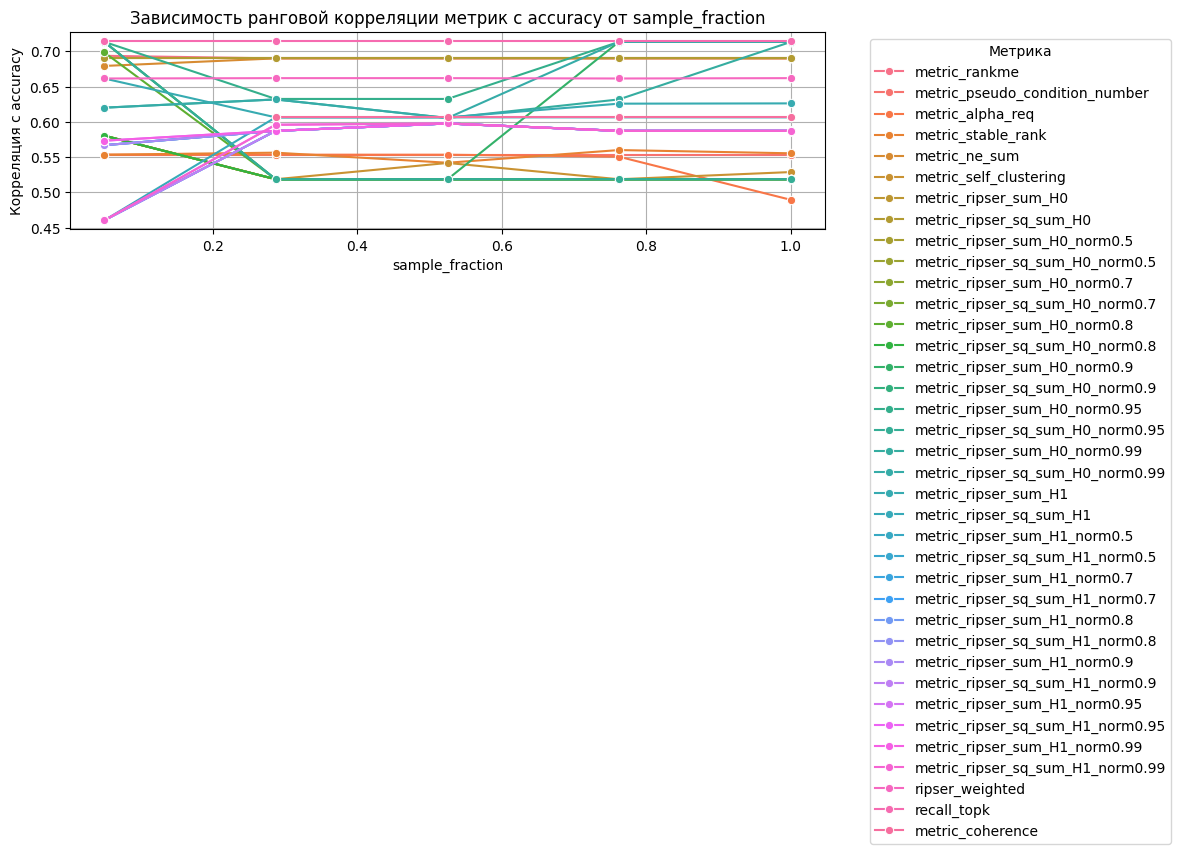

embedding_dim


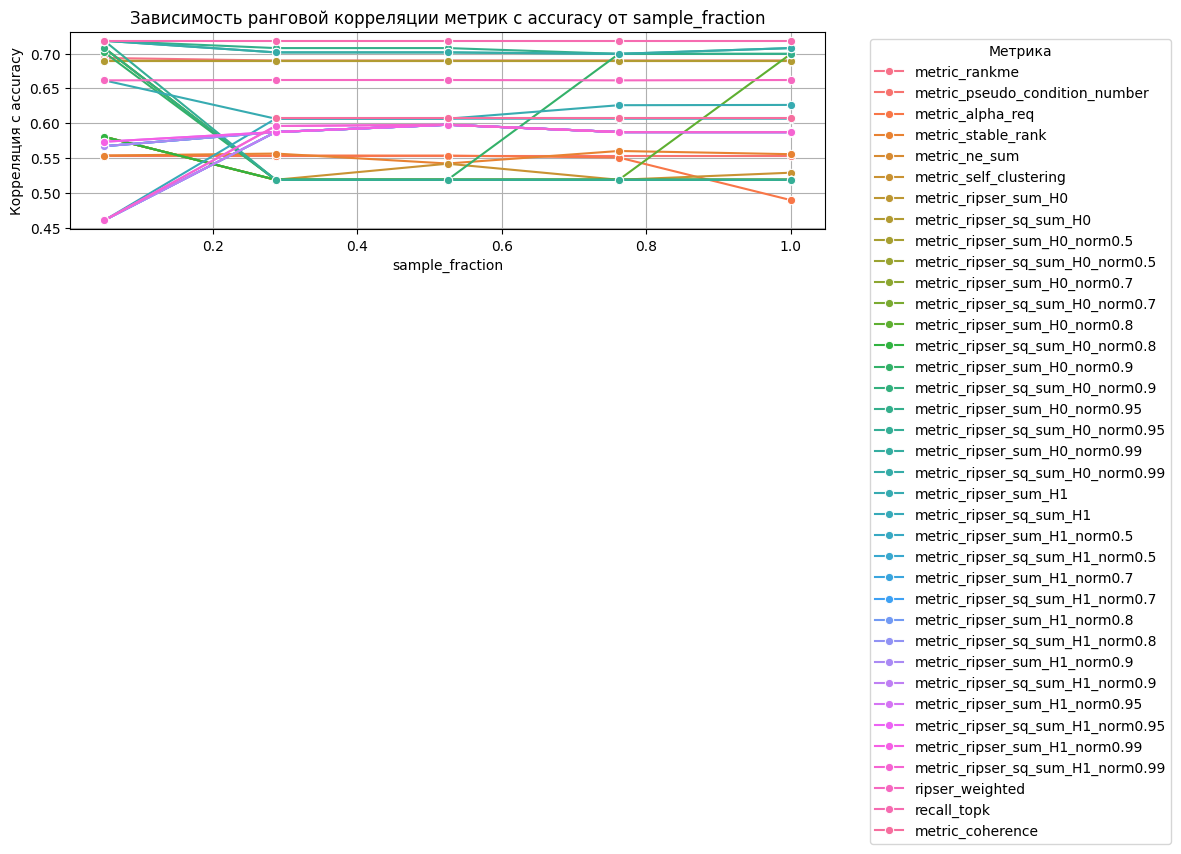

category_embedding_dim


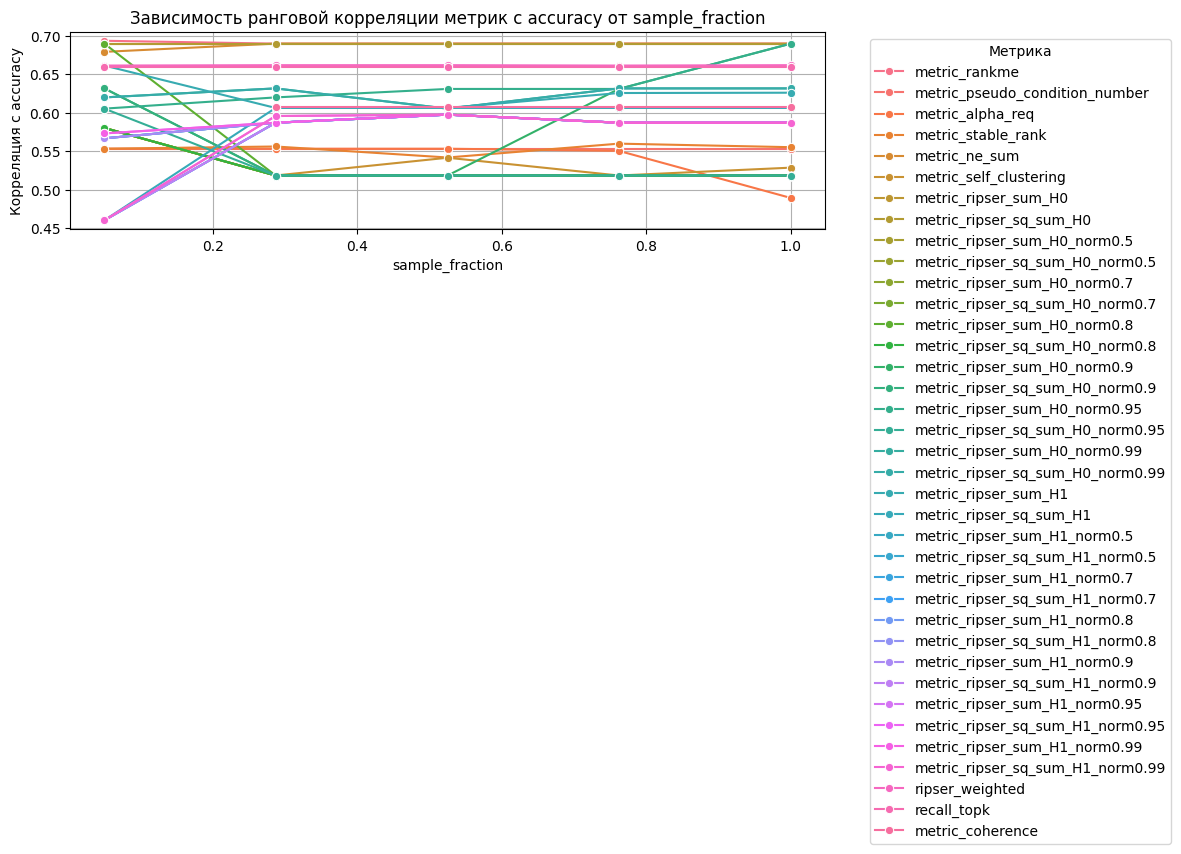

hidden_size


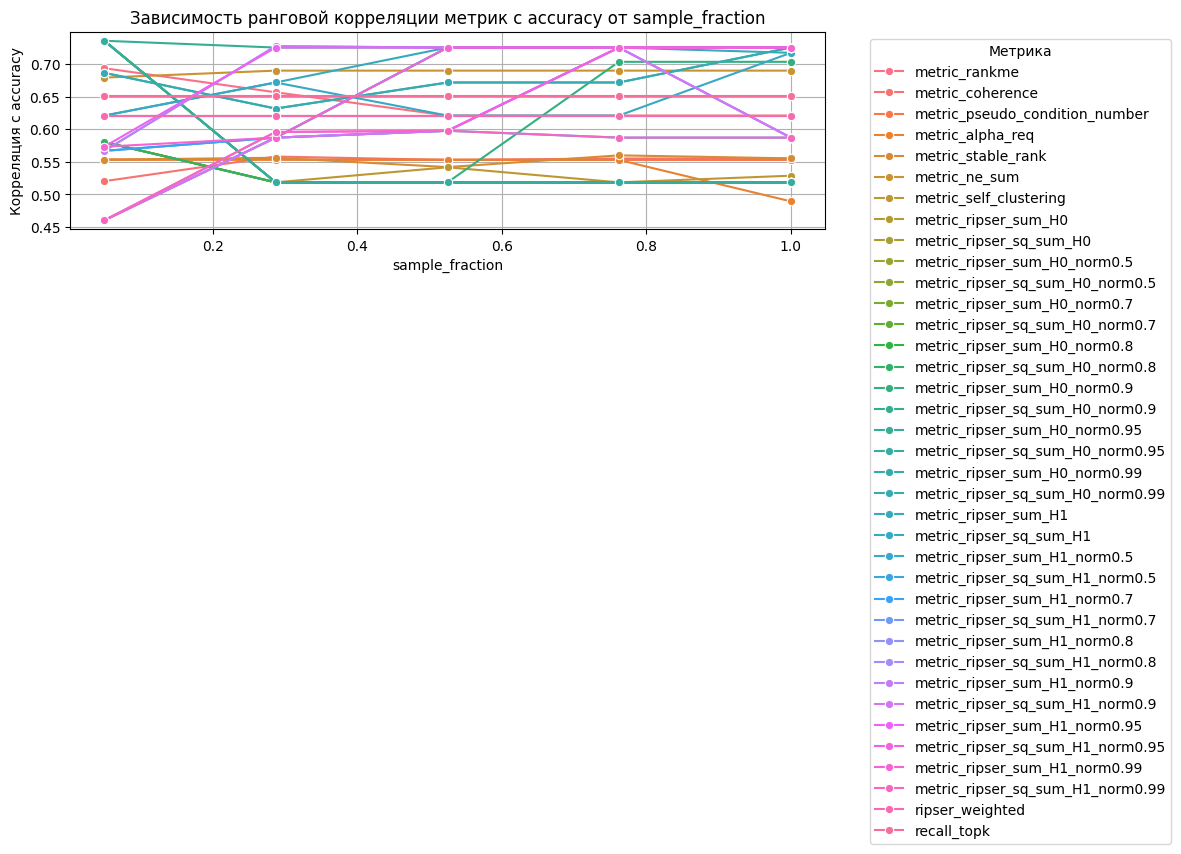

In [39]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [40]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_rankme                       0.69185
metric_ripser_sum_H0                0.69000
metric_ripser_sq_sum_H0             0.69000
recall_topk                         0.68500
metric_ne_sum                       0.68465
ripser_weighted                     0.66175
metric_ripser_sum_H1                0.63395
metric_ripser_sq_sum_H0_norm0.99    0.62595
metric_ripser_sum_H0_norm0.99       0.62595
metric_ripser_sum_H0_norm0.95       0.61280
metric_coherence                    0.60730
metric_ripser_sum_H0_norm0.8        0.60430
metric_ripser_sum_H1_norm0.95       0.58025
metric_ripser_sum_H1_norm0.99       0.58025
metric_ripser_sum_H1_norm0.7        0.57705
metric_ripser_sum_H1_norm0.5        0.57705
metric_ripser_sum_H1_norm0.8        0.57705
metric_ripser_sum_H1_norm0.9        0.57705
metric_ripser_sq_sum_H0_norm0.9     0.57520
metric_ripser_sum_H0_norm0.9        0.57520
metric_ripser_sq_sum_H0_norm0.95    0.56205
metric_stable_rank                  0.55485
metric_alpha_r

In [41]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ne_sum                       0.6900
metric_rankme                       0.6900
metric_ripser_sum_H0_norm0.9        0.6900
metric_ripser_sum_H0                0.6900
metric_ripser_sq_sum_H0             0.6900
metric_ripser_sum_H0_norm0.95       0.6900
recall_topk                         0.6850
ripser_weighted                     0.6620
metric_ripser_sq_sum_H0_norm0.99    0.6318
metric_ripser_sum_H0_norm0.99       0.6318
metric_ripser_sum_H1                0.6262
metric_coherence                    0.6073
metric_ripser_sq_sum_H1             0.6064
metric_ripser_sum_H1_norm0.99       0.5872
metric_ripser_sum_H1_norm0.95       0.5872
metric_ripser_sq_sum_H1_norm0.99    0.5872
metric_ripser_sq_sum_H1_norm0.95    0.5872
metric_ripser_sq_sum_H1_norm0.7     0.5872
metric_ripser_sq_sum_H1_norm0.8     0.5872
metric_ripser_sq_sum_H1_norm0.5     0.5872
metric_ripser_sq_sum_H1_norm0.9     0.5872
metric_ripser_sum_H1_norm0.5        0.5872
metric_ripser_sum_H1_norm0.7        

In [41]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_self_clustering              0.76940
metric_stable_rank                  0.76864
recall_topk                         0.76810
metric_ripser_sq_sum_H0             0.73910
metric_ripser_sum_H0                0.73910
metric_ripser_sq_sum_H0_norm0.5     0.72278
metric_rankme                       0.72100
metric_ripser_sum_H0_norm0.5        0.72008
metric_ne_sum                       0.71728
metric_ripser_sum_H0_norm0.7        0.71726
metric_ripser_sq_sum_H0_norm0.8     0.71726
metric_ripser_sum_H0_norm0.8        0.71726
metric_ripser_sq_sum_H0_norm0.7     0.71726
metric_ripser_sq_sum_H1             0.70934
metric_ripser_sum_H0_norm0.95       0.70924
metric_pseudo_condition_number      0.70924
metric_ripser_sq_sum_H0_norm0.95    0.70924
ripser_weighted                     0.70822
metric_ripser_sq_sum_H0_norm0.9     0.70814
metric_ripser_sum_H0_norm0.9        0.70814
metric_coherence                    0.70315
metric_ripser_sum_H1_norm0.99       0.70070
metric_alpha_r

In [74]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

# Standard deviation of score of best param selection

In [43]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


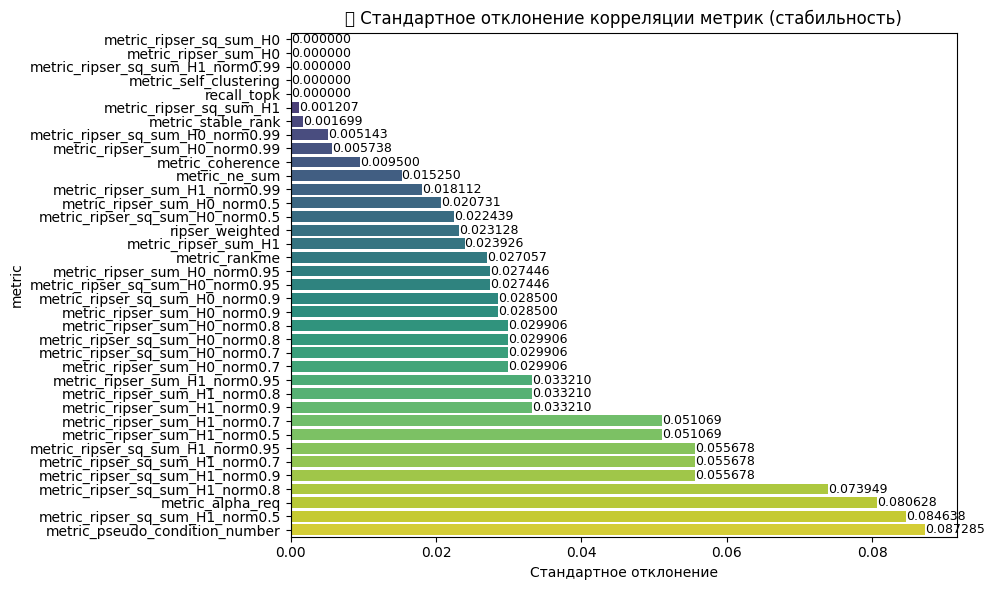

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


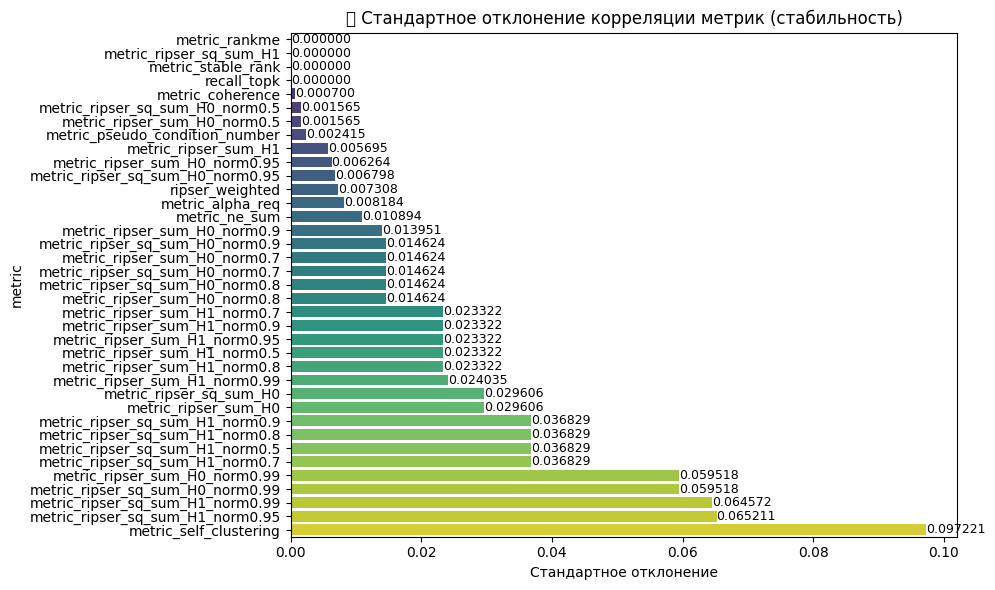

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


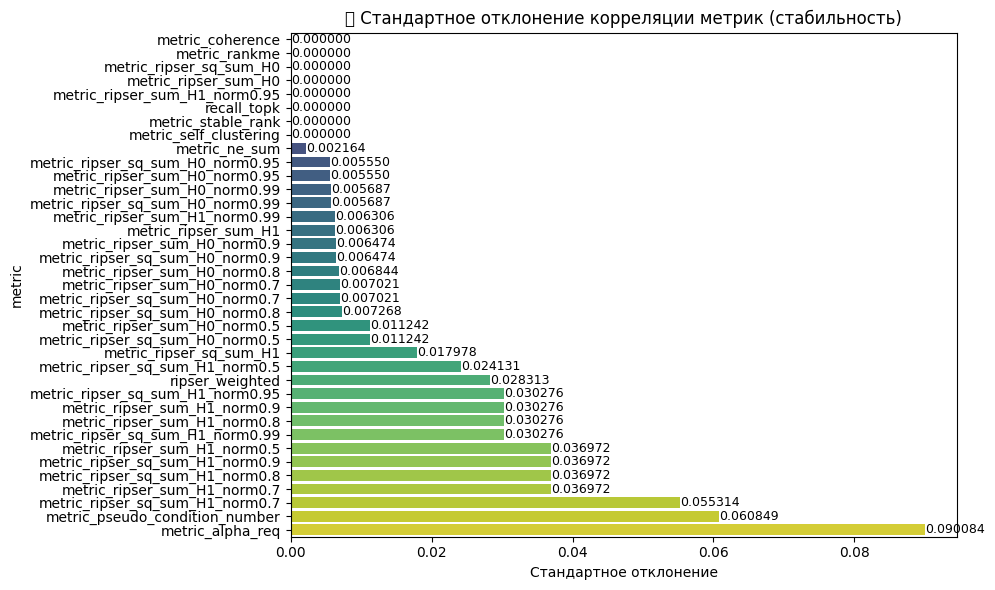

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


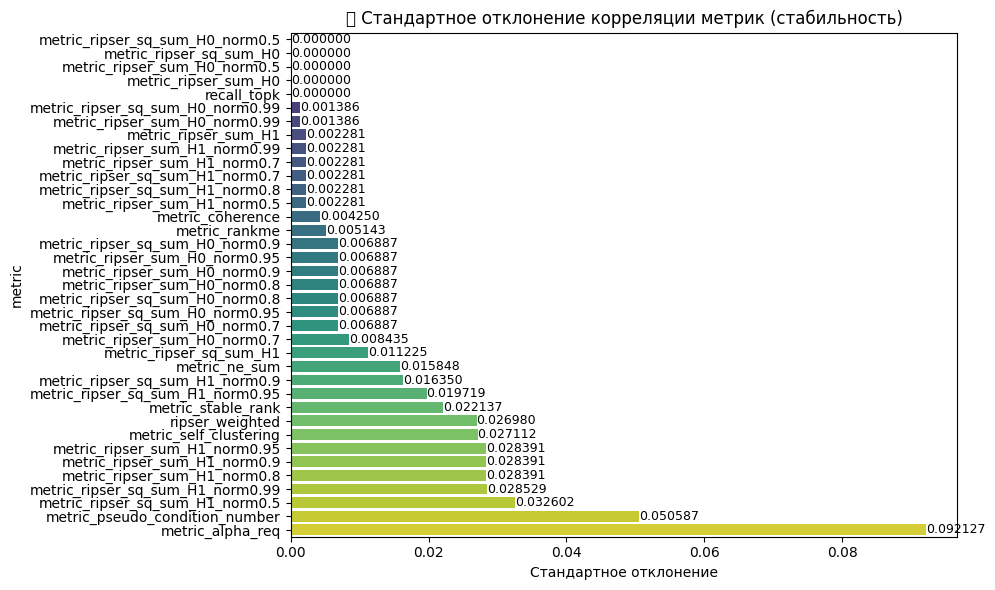

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


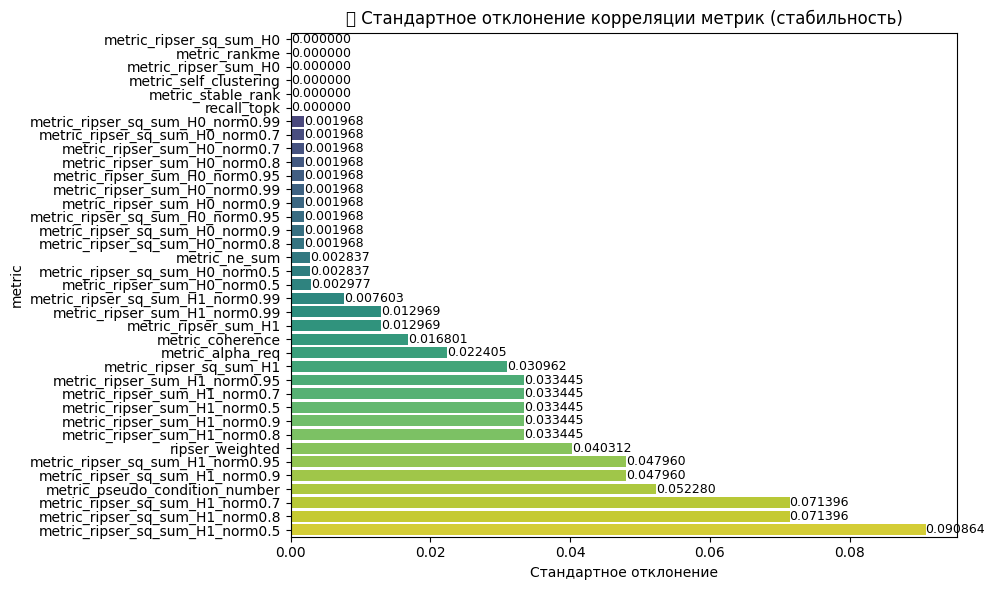

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


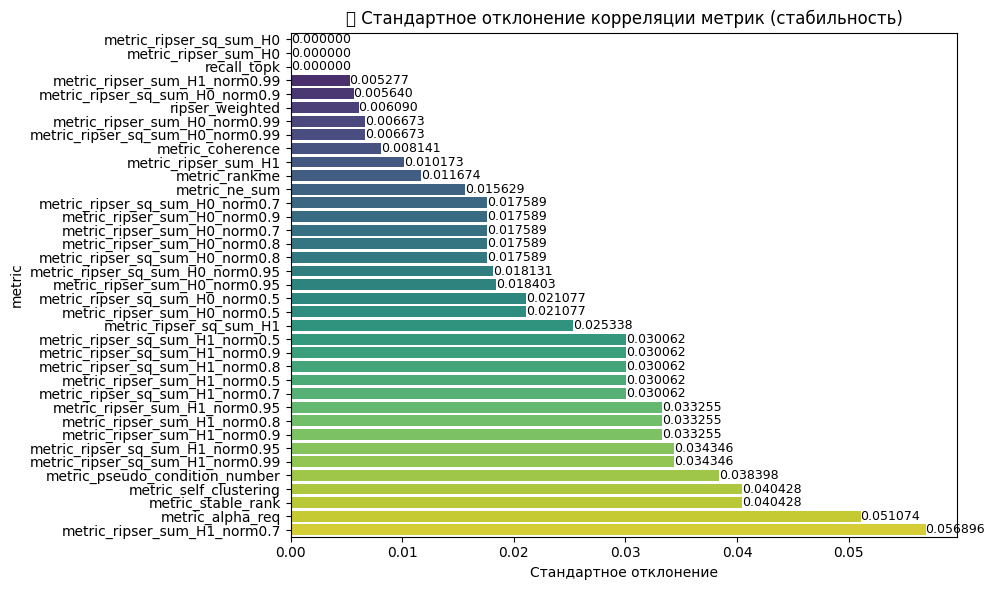

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


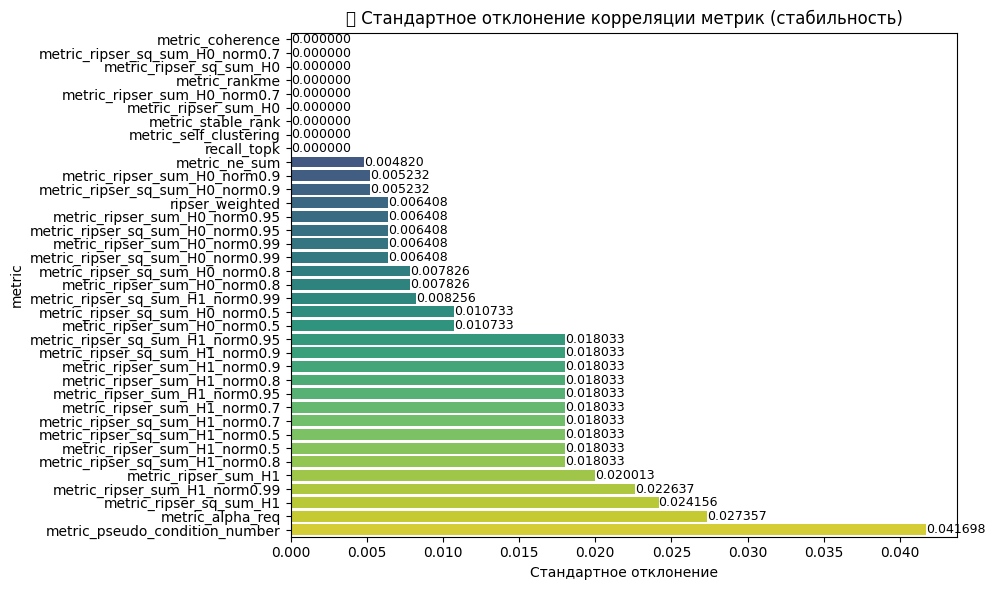

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


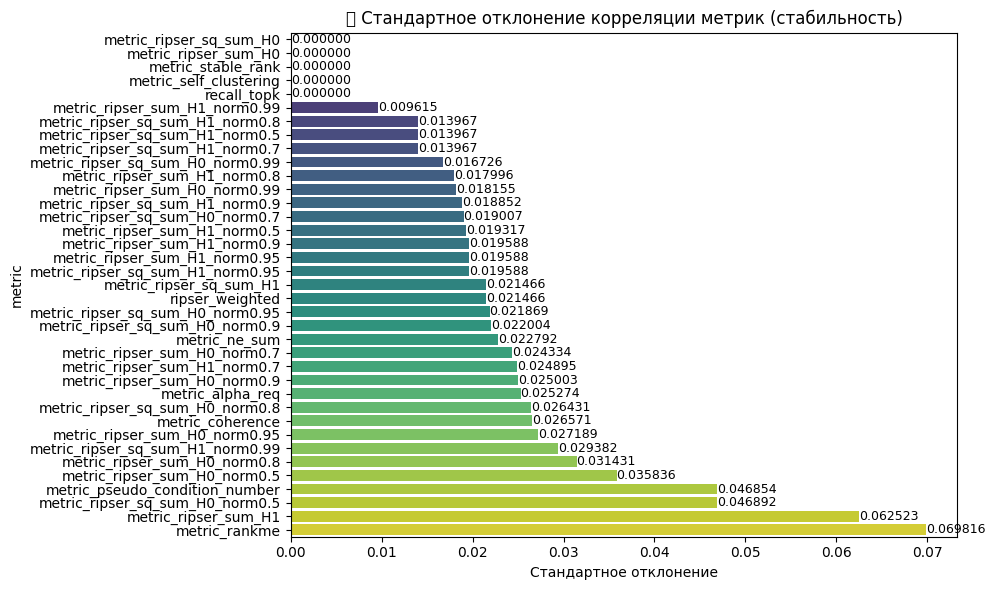

In [45]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()